# Epic Mustache Detector v2
Transfer learning med MobileNetV2 för bättre generalisering.

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.16.2


## Ladda dataset

In [9]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
DATA_DIR = "data/epic_dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Klasser:", train_ds.class_names)
print("=> epic=0, thin=1 => epic_score = 1 - model_output")

Found 469 files belonging to 2 classes.
Using 376 files for training.
Found 469 files belonging to 2 classes.
Using 93 files for validation.
Klasser: ['epic', 'thin']
=> epic=0, thin=1 => epic_score = 1 - model_output


## Bygg modellen med MobileNetV2

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

# MobileNetV2 förtränad på ImageNet
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # frys basmodellen

epic_model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./127.5, offset=-1),  # MobileNetV2 vill ha [-1, 1]
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

epic_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Steg 1: Träna med fryst bas

In [11]:
epic_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history1 = epic_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.4947 - loss: 0.8307 - val_accuracy: 0.6344 - val_loss: 0.7061
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5931 - loss: 0.6985 - val_accuracy: 0.6774 - val_loss: 0.6148
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6516 - loss: 0.6406 - val_accuracy: 0.7204 - val_loss: 0.5604
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7048 - loss: 0.5987 - val_accuracy: 0.7419 - val_loss: 0.5298
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.7367 - loss: 0.5420 - val_accuracy: 0.7419 - val_loss: 0.5352
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7261 - loss: 0.5196 - val_accuracy: 0.7527 - val_loss: 0.5166
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7553 - loss: 0.4967 - val_accuracy: 0.7527 - val_loss: 0.5061
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.7713 - loss: 0.4564 - val_accuracy: 0.7957 - v

## Steg 2: Fine-tuning — tina upp de sista lagren

In [12]:
# Tina upp de sista 30 lagren i basmodellen
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Lägre learning rate vid fine-tuning
epic_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history2 = epic_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop2]
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.7287 - loss: 0.5648 - val_accuracy: 0.8602 - val_loss: 0.3773
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7819 - loss: 0.4890 - val_accuracy: 0.8710 - val_loss: 0.3680
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8059 - loss: 0.4282 - val_accuracy: 0.8710 - val_loss: 0.3655
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8059 - loss: 0.4020 - val_accuracy: 0.8710 - val_loss: 0.3690
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.7872 - loss: 0.4327 - val_accuracy: 0.8817 - val_loss: 0.3633
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.8351 - loss: 0.3826 - val_accuracy: 0.8817 - val_loss: 0.3622
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8431 - loss: 0.3748 - val_accuracy: 0.8817 - val_loss: 0.3642
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.8165 - loss: 0.3751 - val_accuracy: 0.8817 -

## Utvärdering

In [13]:
loss, acc = epic_model.evaluate(val_ds)
print(f"Val accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8817 - loss: 0.3563
Val accuracy: 0.8817


2026-06-02 10:08:33.052173: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


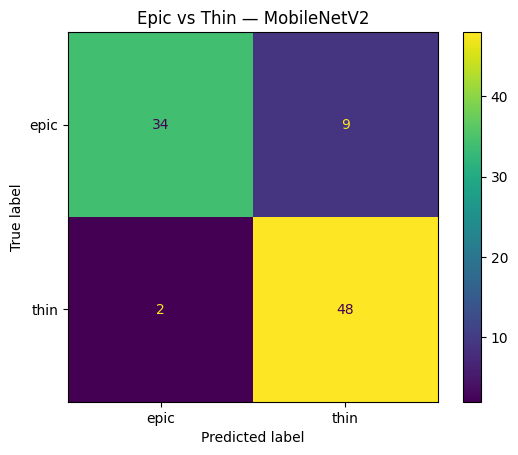

In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    y_true.extend(labels.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_ds.class_names
)
disp.plot(values_format="d")
plt.title("Epic vs Thin — MobileNetV2")
plt.show()

## Spara modellen

In [15]:
import os
os.makedirs("models", exist_ok=True)
epic_model.save("models/epic_detector.keras")
print("Sparad!")

Sparad!
